# Shaman Play-Style Axes — most-played non-Warrior class

The same deck-conditioned 4-axis pipeline as `warrior_playstyle_axes.ipynb`, applied to the
**most-played non-Warrior class: Shaman** (33,258 ranked games — essentially tied with Warrior for
#1). This shows the method is **class-agnostic**: only the population and the archetype baselines
change.

## One extra step versus the Warrior notebook

There was no pre-built dataframe for Shaman (only `warrior_dataframes.pkl` existed), so this
notebook **builds the Shaman games frame itself** from the monthly dumps. The per-game numeric
features (`rounds`, `mana_eff`, `coin_turn`, `first_turn`) are reconstructed with a parser that was
**validated against the Warrior frame** before use:

| feature | exact-match vs Warrior frame |
|---|---|
| `rounds` | 100.0% |
| `mana_eff` | 99.1% |
| `coin_turn` | 99.8% |
| `first_turn` | 99.9% |

So Shaman numbers are directly comparable to the Warrior ones. Key formulas: `turn` is the round
number; `rounds` = max turn; `mana_available` = Σ min(k,10) over the player's turns (+1 if the Coin
was played); `mana_spent` = Σ mana of played non-Coin cards.

Tag recipe, feature dictionary, and axis formulas are identical to the Warrior notebook — see it for
the details. Outputs `shaman_playstyle_axes.csv` and caches the built data to
`shaman_dataframes.pkl` / `shaman_me_cards.pkl`.

## Stage 0 — Config

In [1]:
import json, glob, os, re, pickle, time
import numpy as np
import pandas as pd

ROOT      = r"d:\test"
DUMP_GLOB = os.path.join(ROOT, "dataset", "hearthstonemap", "20*.json")
META_PATH = os.path.join(ROOT, "hearthstonemap-master", "hearthstonemap-master",
                         "data-processing", "cards_meta.json")
CLASS     = "Shaman"
GAMES_PKL = os.path.join(ROOT, "shaman_dataframes.pkl")
CACHE_PKL = os.path.join(ROOT, "shaman_me_cards.pkl")
COIN_ID          = "GAME_005"
MIN_GAMES_PLAYER = 15
DECK_MIN_GAMES   = 30
DECK_MIN_PLAYERS = 5

## Stage 1a — Build the Shaman games frame + played-card lists

One pass over the 16 monthly dumps: keep ranked Shaman games, reconstruct the numeric features
(parser validated on Warrior), and grab the player's `card_history`. Cached after first run
(~15 s).

In [2]:
def recon_numeric(g):
    ch = g.get("card_history") or []
    if not ch: return None
    me = [c for c in ch if c["player"] == "me"]
    if not me: return None
    turns = [c["turn"] for c in ch]
    R = max(turns)
    me_turns = {c["turn"] for c in me}
    me_nc = [c for c in me if c["card"].get("id") != COIN_ID]
    coin_plays = [c["turn"] for c in me if c["card"].get("id") == COIN_ID]
    me_first = (g.get("coin") == False)              # no coin => went first
    n_me = R if me_first else (R if R in me_turns else R - 1)
    avail = sum(min(k, 10) for k in range(1, n_me + 1)) + (1 if coin_plays else 0)
    spent = sum((c["card"].get("mana") or 0) for c in me_nc)
    return dict(rounds=float(R),
                mana_eff=(spent / avail if avail > 0 else np.nan),
                coin_turn=(float(min(coin_plays)) if coin_plays else np.nan),
                first_turn=float(min(me_turns)))

def build_class(cls, dump_glob):
    rows, plays = [], {}
    for f in sorted(glob.glob(dump_glob)):
        j = json.load(open(f, encoding="utf-8"))
        for g in j["games"]:
            if g.get("hero") != cls or g.get("mode") != "ranked":
                continue
            gid = int(g["id"]); num = recon_numeric(g)
            rows.append(dict(game_id=gid, user_hash=g["user_hash"],
                             hero_deck=g.get("hero_deck") or "Unknown",
                             rank=g.get("rank"), win=1 if g.get("result") == "win" else 0,
                             has_coin=bool(g.get("coin")),
                             **(num or dict(rounds=np.nan, mana_eff=np.nan,
                                            coin_turn=np.nan, first_turn=np.nan))))
            ch = g.get("card_history") or []
            me = [{"turn": c["turn"], "id": c["card"].get("id"),
                   "name": c["card"].get("name"), "mana": c["card"].get("mana")}
                  for c in ch if c.get("player") == "me" and c.get("card")]
            if me: plays[gid] = me
        del j
    return pd.DataFrame(rows), plays

t0 = time.time()
if os.path.exists(GAMES_PKL) and os.path.exists(CACHE_PKL):
    games = pickle.load(open(GAMES_PKL, "rb"))["games"]
    plays = pickle.load(open(CACHE_PKL, "rb"))
    print(f"loaded cache: {len(games)} games, {len(plays)} with cards")
else:
    games, plays = build_class(CLASS, DUMP_GLOB)
    pickle.dump({"games": games}, open(GAMES_PKL, "wb"))
    pickle.dump(plays, open(CACHE_PKL, "wb"))
    print(f"built {len(games)} {CLASS} games ({len(plays)} w/ cards) in {time.time()-t0:.1f}s")

games["game_id"] = games["game_id"].astype(int)
print(f"{CLASS}: {len(games)} games | {games['user_hash'].nunique()} players")
games["hero_deck"].value_counts(dropna=False)

loaded cache: 33258 games, 31959 with cards
Shaman: 33258 games | 164 players


hero_deck
Midrange    9051
Aggro       8458
Unknown     8441
Token       2834
Jade        2349
Control     2125
Name: count, dtype: int64

## Stage 1b — Card tags + per-game features  *(identical to the Warrior notebook)*

In [3]:
meta = json.load(open(META_PATH, encoding="utf-8"))
def build_tags(meta):
    T = {}
    for c in meta:
        cid = c.get("id")
        if not cid: continue
        typ = c.get("type"); text = (c.get("text") or "").lower()
        mech = set(c.get("mechanics") or [])
        deal_dmg = bool(re.search(r"deal\s+\$?\d+\s+damage", text))
        removal  = (("destroy" in text and "minion" in text)
                    or bool(re.search(r"damage to (a|all|an|the)?\s*\w*\s*minion", text))
                    or "destroy all minions" in text)
        T[cid] = dict(minion=(typ=="MINION"), weapon=(typ=="WEAPON"), spell=(typ=="SPELL"),
                      cost=c.get("cost"), deal_dmg=deal_dmg, removal=removal,
                      draw=("draw" in text),
                      heal=(("restore" in text and "health" in text) or "heal" in text),
                      taunt=("TAUNT" in mech or "taunt" in text),
                      charge=("CHARGE" in mech or "charge" in text),
                      rng=("DISCOVER" in mech or "random" in text or "discover" in text))
    return T
T = build_tags(meta)
DEFAULT = dict(minion=False, weapon=False, spell=False, cost=None, deal_dmg=False,
               removal=False, draw=False, heal=False, taunt=False, charge=False, rng=False)

def game_features(cards):
    noncoin = [c for c in cards if c["id"] != COIN_ID]
    n = len(noncoin)
    if n == 0: return None
    def tg(c): return T.get(c["id"], DEFAULT)
    costs = [c["mana"] for c in noncoin if c["mana"] is not None]
    total_mana = sum(costs) or 1.0
    def share(p): return sum(bool(p(c)) for c in noncoin) / n
    early = sum((c["mana"] or 0) for c in noncoin if tg(c)["minion"] and c["turn"] <= 4)
    return dict(avg_cost=float(np.mean(costs)) if costs else np.nan,
                minion_share=share(lambda c: tg(c)["minion"]),
                draw_share=share(lambda c: tg(c)["draw"]),
                topend_share=share(lambda c: (c["mana"] or 0) >= 7),
                cheap_share=share(lambda c: (c["mana"] or 0) <= 2),
                aggro_share=share(lambda c: tg(c)["charge"] or tg(c)["deal_dmg"]),
                control_share=share(lambda c: tg(c)["removal"] or tg(c)["heal"]
                                    or tg(c)["taunt"] or tg(c)["draw"]),
                rng_share=share(lambda c: tg(c)["rng"]),
                early_commit=early/total_mana)

rows = []
for gid, cards in plays.items():
    f = game_features(cards)
    if f: f["game_id"] = gid; rows.append(f)
tagdf = pd.DataFrame(rows)

NUM = ["rounds", "mana_eff", "coin_turn", "first_turn"]
feat = games[["game_id", "user_hash", "hero_deck", "rank", "win"] + NUM].merge(
    tagdf, on="game_id", how="inner")
FEATURES = ["rounds", "avg_cost", "mana_eff", "coin_turn",
            "minion_share", "draw_share", "topend_share", "cheap_share",
            "aggro_share", "control_share", "rng_share", "early_commit"]
print("feature matrix:", feat.shape)
feat[["hero_deck"] + FEATURES].head()

feature matrix: (31955, 18)


,hero_deck,rounds,avg_cost,mana_eff,coin_turn,minion_share,draw_share,topend_share,cheap_share,aggro_share,control_share,rng_share,early_commit
0,Midrange,7.0,2.000,0.642857,NaN,0.888889,0.0000,0.0,0.777778,0.0,0.0000,0.111111,0.388889
1,Midrange,12.0,2.625,0.636364,1.0,0.625000,0.0625,0.0,0.500000,0.0,0.3125,0.062500,0.285714
2,Midrange,0.0,5.000,NaN,NaN,1.000000,0.0000,0.0,0.000000,0.0,0.0000,0.000000,1.000000
3,Midrange,0.0,5.000,NaN,NaN,1.000000,0.0000,0.0,0.000000,0.0,0.0000,0.000000,1.000000
4,Midrange,0.0,5.000,NaN,NaN,1.000000,0.0000,0.0,0.000000,0.0,0.0000,0.000000,1.000000


## Stage 2 — Deck-conditioned baseline (per Shaman archetype)

Robust median/MAD baseline per archetype, guards (≥30 games & ≥5 players) else pooled to a
class-level `POOL` baseline. Shaman archetypes: Midrange, Aggro, Token, Jade, Control (+ Unknown).

In [4]:
def rcs(s):
    s = s.dropna()
    if len(s) == 0: return 0.0, 1.0
    med = float(np.median(s)); mad = float(np.median(np.abs(s-med)))*1.4826
    if mad < 1e-9:
        sd = float(s.std()); mad = sd if sd > 1e-9 else 1.0
    return med, mad

ds = games.groupby("hero_deck")["user_hash"].agg(["count", "nunique"])
qualified = set(ds[(ds["count"] >= DECK_MIN_GAMES) & (ds["nunique"] >= DECK_MIN_PLAYERS)].index)
qualified.discard("Unknown")
print("qualified archetypes:", sorted(qualified))

baselines = {}
for f in FEATURES:
    baselines[("POOL", f)] = rcs(feat[f])
    for dk in qualified:
        baselines[(dk, f)] = rcs(feat.loc[feat["hero_deck"] == dk, f])
def deck_key(dk): return dk if dk in qualified else "POOL"

Z = feat[["game_id", "user_hash", "hero_deck"]].copy()
for f in FEATURES:
    cs = feat["hero_deck"].map(lambda dk: baselines[(deck_key(dk), f)])
    Z[f] = (feat[f] - cs.map(lambda t: t[0]).astype(float)) / cs.map(lambda t: t[1]).astype(float)
print("deck-adjusted residuals Z:", Z.shape)

qualified archetypes: ['Aggro', 'Control', 'Jade', 'Midrange', 'Token']
deck-adjusted residuals Z: (31955, 15)


## Stage 3 — Axis scoring  *(same formulas / weights)*

In [5]:
AXES = {
    "aggro_control": [("rounds",-1,.30),("avg_cost",-1,.20),("aggro_share",+1,.20),
                      ("control_share",-1,.20),("cheap_share",+1,.10)],
    "tempo_value":   [("draw_share",-1,.35),("minion_share",+1,.25),
                      ("topend_share",-1,.20),("coin_turn",-1,.20)],
    "risk":          [("rng_share",+1,.60),("early_commit",+1,.40)],
    "greedy_eff":    [("mana_eff",-1,.40),("avg_cost",+1,.30),("topend_share",+1,.30)],
}
AX = list(AXES.keys())
def standardize(s):
    sd = s.std(); return (s - s.mean()) / (sd if sd > 1e-9 else 1.0)

gb = Z.groupby("user_hash"); ngames = gb.size()
players = ngames[ngames >= MIN_GAMES_PLAYER].index
Zp = gb[FEATURES].mean().loc[players]
axis_scores = pd.DataFrame(index=players)
for axis, terms in AXES.items():
    axis_scores[axis] = np.tanh(standardize(sum(sg*w*Zp[f] for f,sg,w in terms)))
axis_scores["n_games"] = ngames.loc[players]
axis_scores.to_csv(os.path.join(ROOT, "shaman_playstyle_axes.csv"))
print(f"scored {len(axis_scores)} {CLASS} players (>= {MIN_GAMES_PLAYER} games) -> shaman_playstyle_axes.csv")
axis_scores.round(3).head(12)

scored 130 Shaman players (>= 15 games) -> shaman_playstyle_axes.csv


,aggro_control,tempo_value,risk,greedy_eff,n_games
user_hash,,,,,
01DE27F723DBA6AA3F3D9B085A292626,-0.929,0.675,0.317,0.173,118
02089C8A058B9FF2B2EE88F072AA7821,0.884,0.238,0.542,-0.647,19
02BE56C56050E98A011C31340F4376F0,-0.890,0.924,0.154,0.598,111
03019D3B5094E121EBCEEB6F21F0FBE5,0.314,-0.631,-0.847,0.558,753
03C9A80213B75DD46F4C1DF6EA966B42,-0.686,-0.108,0.765,-0.308,121
03DDBE33338D65E625315EC0ACD3CA17,0.949,0.632,0.963,-0.765,45
0595B1E1C48983DE1176D93870B0FD6F,0.556,-0.011,-0.614,0.458,125
0675131D304DFB550A83C54A92568BBE,0.207,-0.302,0.752,-0.650,219
08559CE836A3FD14B06DAAE60F74C1B8,0.112,-0.619,-0.949,0.552,112


## Stage 4 — Validation

In [6]:
corr = axis_scores[AX].corr()
print("4x4 axis correlation:")
display(corr.round(2))
print("Note the class difference vs Warrior: here risk<->greed correlate strongly")
print("(Shaman's RNG/Discover decks — Aggro/Token — are also the cheap, efficient ones).")

4x4 axis correlation:


,aggro_control,tempo_value,risk,greedy_eff
aggro_control,1.00,0.12,0.31,-0.62
tempo_value,0.12,1.00,0.03,0.03
risk,0.31,0.03,1.00,-0.74
greedy_eff,-0.62,0.03,-0.74,1.00


Note the class difference vs Warrior: here risk<->greed correlate strongly
(Shaman's RNG/Discover decks — Aggro/Token — are also the cheap, efficient ones).


In [7]:
def score_subset(idx):
    sg = Z.loc[idx].groupby("user_hash")[FEATURES].mean()
    out = pd.DataFrame(index=sg.index)
    for axis, terms in AXES.items():
        out[axis] = standardize(sum(s*w*sg[f] for f,s,w in terms))
    return out
order = Z.groupby("user_hash").cumcount()
A = score_subset(Z.index[order%2==0]); B = score_subset(Z.index[order%2==1])
common = A.index.intersection(B.index).intersection(players)
print(f"split-half on {len(common)} players:")
for axis in AX:
    print(f"  {axis:14s} r = {np.corrcoef(A.loc[common,axis],B.loc[common,axis])[0,1]:+.2f}")

split-half on 130 players:
  aggro_control  r = +0.81
  tempo_value    r = +0.89
  risk           r = +0.80
  greedy_eff     r = +0.93


In [8]:
print("between/within variance ratio (higher = more trait-like):")
for axis, terms in AXES.items():
    Zc = Z.copy(); Zc["R"] = sum(s*w*Zc[f] for f,s,w in terms)
    sub = Zc[Zc.user_hash.isin(players)]; grand = sub["R"].mean()
    pm = sub.groupby("user_hash")["R"]
    bet = ((pm.mean()-grand)**2*pm.size()).sum()/(len(players)-1)
    wit = sub.groupby("user_hash")["R"].apply(lambda s:((s-s.mean())**2).sum()).sum()/(len(sub)-len(players))
    print(f"  {axis:14s} {bet/wit:6.2f}")

between/within variance ratio (higher = more trait-like):
  aggro_control   16.68
  tempo_value     47.92
  risk            32.91
  greedy_eff      39.90


In [9]:
# cross-deck stability: same player, different Shaman archetype
pc = feat[feat.user_hash.isin(players)].groupby(["user_hash","hero_deck"]).size()
pairs = []
for uh in players:
    dks = pc.loc[uh]; dks = dks[(dks.index.isin(qualified)) & (dks >= 10)]
    if len(dks) >= 2: pairs.append((uh, list(dks.index)))
print(f"{len(pairs)} players span >=2 qualified archetypes (>=10 games each)")
if pairs:
    spreads = []
    for uh, dks in pairs:
        per = pd.DataFrame([Z.loc[(Z.user_hash==uh)&(Z.hero_deck==dk), FEATURES].mean() for dk in dks])
        spreads.append(per.std().mean())
    print(f"mean within-player across-deck feature std: {np.mean(spreads):.2f} (vs ~1.0 null)")

81 players span >=2 qualified archetypes (>=10 games each)
mean within-player across-deck feature std: 0.37 (vs ~1.0 null)


In [10]:
print("face-validity extremes (player hash prefix):")
for axis in AX:
    hi, lo = axis_scores[axis].idxmax(), axis_scores[axis].idxmin()
    print(f"  {axis:14s} max={axis_scores.loc[hi,axis]:+.2f} ({hi[:8]})   "
          f"min={axis_scores.loc[lo,axis]:+.2f} ({lo[:8]})")

face-validity extremes (player hash prefix):
  aggro_control  max=+0.98 (BC96E62D)   min=-1.00 (30D21636)
  tempo_value    max=+0.99 (08591996)   min=-0.99 (0A89B858)
  risk           max=+0.96 (03DDBE33)   min=-1.00 (C7AE0B5C)
  greedy_eff     max=+0.99 (E593DFF3)   min=-0.95 (883C1319)


## Profile plots — most extreme Shaman pilot on each axis

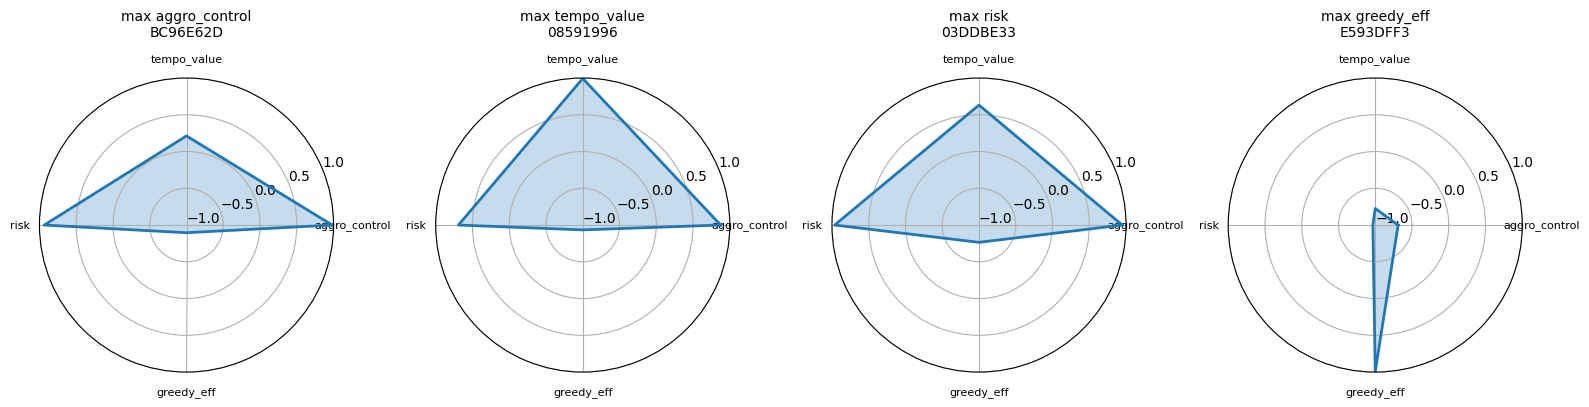

In [11]:
import matplotlib.pyplot as plt
def radar(ax, vals, labels, title):
    ang = np.linspace(0,2*np.pi,len(labels),endpoint=False).tolist()
    v=list(vals)+[vals[0]]; a=ang+[ang[0]]
    ax.plot(a,v,lw=2); ax.fill(a,v,alpha=.25)
    ax.set_xticks(ang); ax.set_xticklabels(labels,fontsize=8)
    ax.set_ylim(-1,1); ax.set_yticks([-1,-.5,0,.5,1]); ax.set_title(title,fontsize=10,pad=12)
picks = [axis_scores[a].idxmax() for a in AX]
fig, axs = plt.subplots(1, 4, subplot_kw=dict(polar=True), figsize=(16, 4))
for ax, uh, a in zip(axs, picks, AX):
    radar(ax, axis_scores.loc[uh, AX].values, AX, f"max {a}\n{uh[:8]}")
plt.tight_layout(); plt.show()

## Findings (Shaman) — and what carries across classes

- **The method is class-agnostic.** With Shaman's own archetype baselines, reliability is as strong
  as Warrior or stronger: split-half r ≈ **0.80–0.93**, between/within variance ≈ **16–48×**, and
  cross-deck feature drift ≈ **0.37** (same as Warrior) — the deck-adjusted read survives a deck
  switch.
- **A real cross-class difference in axis structure.** In Warrior, `risk` was largely independent;
  in **Shaman, `risk` and `greed/efficiency` are strongly anti-correlated (≈ −0.74)** — because
  Shaman's variance-heavy decks (Aggro / Token, full of random & Discover effects) are also the
  cheap, mana-efficient ones. So "risk-seeking" and "efficient" coincide for Shaman pilots. This is
  exactly the kind of thing the per-class correlation matrix is meant to surface: the *axes* are
  fixed, but how they relate is class-dependent.
- **Same redundancy to resolve:** `aggro_control` vs `greedy_eff` ≈ −0.62 (shared `avg_cost`).
- **Caveat carried over:** tags are text/mechanic heuristics, `risk` rests on two thin proxies, and
  ~26% of Shaman games have `Unknown` deck (pooled to the class baseline).

Pair this with `warrior_playstyle_axes.ipynb`: together they show the pipeline generalizes across
the two most-played classes, while the per-class correlation matrices reveal genuine differences in
how the styles co-occur.